# Predicting variants

In [ ]:
import os
import re
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import matplotlib.pyplot as plt
import tensorflow as tflow
import numpy as np
import tcn
from tensorflow.keras.models import load_model

from utils import prepare_batch, rev_comp

In [ ]:
trans_factors = [
    "GCM1", "MKX", "MSANTD1", "TPRX1", "ZFTA",
    "MYPOP", "CREB3L3", "FIZ1", "ZNF500", "ZNF780B",
    "ZNF831", "ZNF286B", "ZBTB47", "ZNF721", "SP140L",
    "USF3", "ZBED2", "MYF6", "SALL3", "CAMTA1",
    "ZNF367", "ZNF648", "ZNF518B", "ZBED5", "ZNF251",
    "ZNF493", "ZNF20", "LEUTX", "PRDM13", "ZNF395"
]

In [ ]:
models = {}
for tf in trans_factors:
    models[tf] = load_model(f"final_models/{tf}.keras", {"TCN": tcn.TCN})
    

In [ ]:
pattern = re.compile("(\w+)@(\w+).fasta")
files = os.listdir("variants/")

batch_size = 128

In [ ]:
def predict_batch(seqs, model):
    batch = tflow.convert_to_tensor(prepare_batch(seqs))
    predictions_f = model.predict(batch, batch_size=batch_size, verbose=0)

    seqs_r = [rev_comp(seq) for seq in seqs]
    batch_r = tflow.convert_to_tensor(prepare_batch(seqs_r))
    predictions_r = model.predict(batch_r, batch_size=batch_size, verbose=0)

    predictions = np.concatenate([predictions_f, predictions_r], axis=1)
    coef = np.abs(predictions - 0.5)
    weighed_predictions = (predictions*coef).sum(axis=1) / coef.sum(axis=1)
    return weighed_predictions

In [ ]:
for ifile, file in enumerate(files):
    match = pattern.search(file)
    exp = match.group(1)
    tf = match.group(2)
    model = models[tf]
    fout_name = f"variants_results_41bp/{exp}@{tf}.txt"
    fout = open(fout_name, "w")
    seqs = []
    with open(f"variants/{file}") as f:
        for meta, fasta in zip(f,f):
            fasta = fasta.strip().upper()
            center = len(fasta)//2
            seqs.append( fasta[center-20:center+21] )
            if len(seqs) == batch_size:
                predictions_batch = predict_batch(seqs, model)
                for p in predictions_batch:
                    fout.write(f"{p:.5f}\n")
                seqs = []

        if seqs:
            predictions_batch = predict_batch(seqs, model)
            for p in predictions_batch:
                fout.write(f"{p:.5f}\n")
    fout.flush()
    fout.close()
    print(f"{ifile}/{len(files)}\r", end="")

- - -

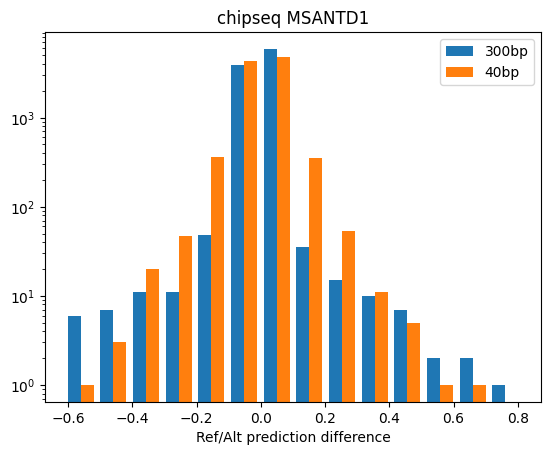

In [8]:
exp_tf = "chipseq@MSANTD1"
difference = []
with open(f"variants_results/{exp_tf}.txt") as f:
    for ref, alt in zip(f,f):
        ref, alt = float(ref), float(alt)
        difference += [ref - alt]

difference1 = []
with open(f"variants_results_41bp/{exp_tf}.txt") as f:
    for ref, alt in zip(f,f):
        ref, alt = float(ref), float(alt)
        difference1 += [ref - alt]

plt.hist([difference, difference1], bins=14, log=True, label=["300bp", "40bp"])

plt.legend()
plt.xlabel("Ref/Alt prediction difference")
plt.title(exp_tf.replace("@", " "))
plt.show()

In [1]:
!tree

.
├── a2g_dataset.py
├── a2g_trainer_final.py
├── data-gatherer.ipynb
├── environment.yml
├── final_models
│   ├── CAMTA1.keras
│   ├── CREB3L3.keras
│   ├── FIZ1.keras
│   ├── GCM1.keras
│   ├── LEUTX.keras
│   ├── MKX.keras
│   ├── MSANTD1.keras
│   ├── MYF6.keras
│   ├── MYPOP.keras
│   ├── PRDM13.keras
│   ├── SALL3.keras
│   ├── SALL3_low.keras
│   ├── SP140L.keras
│   ├── TPRX1.keras
│   ├── USF3.keras
│   ├── ZBED2.keras
│   ├── ZBED5.keras
│   ├── ZBTB47.keras
│   ├── ZFTA.keras
│   ├── ZNF20.keras
│   ├── ZNF251.keras
│   ├── ZNF286B.keras
│   ├── ZNF367.keras
│   ├── ZNF395.keras
│   ├── ZNF493.keras
│   ├── ZNF500.keras
│   ├── ZNF518B.keras
│   ├── ZNF648.keras
│   ├── ZNF721.keras
│   ├── ZNF780B.keras
│   └── ZNF831.keras
├── final_models.zip
├── g2a_dataset.py
├── g2a_trainer_final.py
├── ibis_rSNP.zip
├── models.py
├── output.zip
├── predictions.ipynb
├── predictions_variants.ipynb
├── __pycache__
│   └── utils.cpython-310.pyc
├── README.md
├── utils_imported.py
├── uti